In [13]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

In [14]:
adata = sc.read("Moc_ref_cluster_annotated.h5ad")
adata

AnnData object with n_obs × n_vars = 21116 × 2450
    obs: 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden', 'Neutrophils_score', 'CD8_T_cells_score', 'Macrophages_score', 'Fibroblasts_score', 'DC_score', 'Cancer_cells_score', 'B_cells_score', 'CD4_T_cells_score', 'Monocytes_score', 'NK_cells_score', 'Endothelial_cells_score', 'cell_type', 'cluster_annotation'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'chromosome', 'start', 'end'
    uns: 'batch_colors', 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [15]:
import liana as li
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [16]:
li.rs.show_resources()

['baccin2019',
 'cellcall',
 'cellchatdb',
 'cellinker',
 'cellphonedb',
 'celltalkdb',
 'connectomedb2020',
 'consensus',
 'embrace',
 'guide2pharma',
 'hpmr',
 'icellnet',
 'italk',
 'kirouac2010',
 'lrdb',
 'mouseconsensus',
 'ramilowski2015']

In [23]:
li.mt.rank_aggregate(
    adata,
    groupby='cell_type',
    resource_name='mouseconsensus',
    use_raw=False,
    expr_prop=0.001  # lower threshold, default is 0.1
)

In [24]:
adata.obs['cell_type'].value_counts()

cell_type
Neutrophils          6024
DC                   4378
Cancer_cells         3430
CD8_T_cells          1727
CD4_T_cells          1405
Fibroblasts          1294
Macrophages           915
Monocytes             813
B_cell                478
Endothelial_cells     354
NK_cells              298
Name: count, dtype: int64

In [25]:
adata.obs['cluster_annotation'].value_counts()

cluster_annotation
N2_protumor            2652
N1_antitumor           2477
Cancer_inflamed        1653
Cancer_mesenchymal      952
Treg                    929
General Neutro          895
Cancer_classical        825
CD8_central_memory      597
M2                      481
CD8_effector_memory     434
M1                      434
CD8_exhausted           365
CD8_progenitor          331
CD4_progenitor          290
CD4_Th1                 186
Name: count, dtype: int64

In [26]:
print(adata.uns['liana_res']['source'].unique())
print(adata.uns['liana_res']['target'].unique())

['Fibroblasts' 'Endothelial_cells' 'Macrophages' 'Neutrophils' 'Monocytes'
 'DC' 'Cancer_cells' 'B_cell' 'CD4_T_cells' 'NK_cells' 'CD8_T_cells']
['Neutrophils' 'Monocytes' 'DC' 'CD4_T_cells' 'B_cell' 'Macrophages'
 'Endothelial_cells' 'CD8_T_cells' 'NK_cells' 'Fibroblasts' 'Cancer_cells']


In [61]:
liana_res = adata.uns['liana_res']
ref_df = liana_res[
    (liana_res['source'].isin(['CD4_T_cells', 'CD8_T_cells', 'Macrophages', 'Neutrophils'])) &
    (liana_res['target'] == 'Cancer_cells')
].copy()
ref_df.head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
35418,Neutrophils,Cancer_cells,Il1b,Il1r1_Il1rap,1.793491,0.0,5.943858e-01,0.494173,1.539279,0.039229,0.897572,0.005189,0.001505
7656,CD8_T_cells,Cancer_cells,Apln,Adra2a,0.000539,1.0,2.803673e-07,-0.068010,-0.016464,0.000022,0.005982,1.000000,0.005960
35488,Neutrophils,Cancer_cells,S100a9,Tlr4,1.454657,0.0,3.057558e-01,0.465224,2.216631,0.041926,0.862731,0.005189,0.006101
35486,Neutrophils,Cancer_cells,S100a8,Tlr4,1.423654,0.0,2.989851e-01,0.465308,2.177787,0.042322,0.861400,0.005189,0.006323
35417,Neutrophils,Cancer_cells,Il1b,Adrb2,1.747715,0.0,2.819401e-01,0.569852,1.934478,0.036334,0.857859,0.005189,0.006998


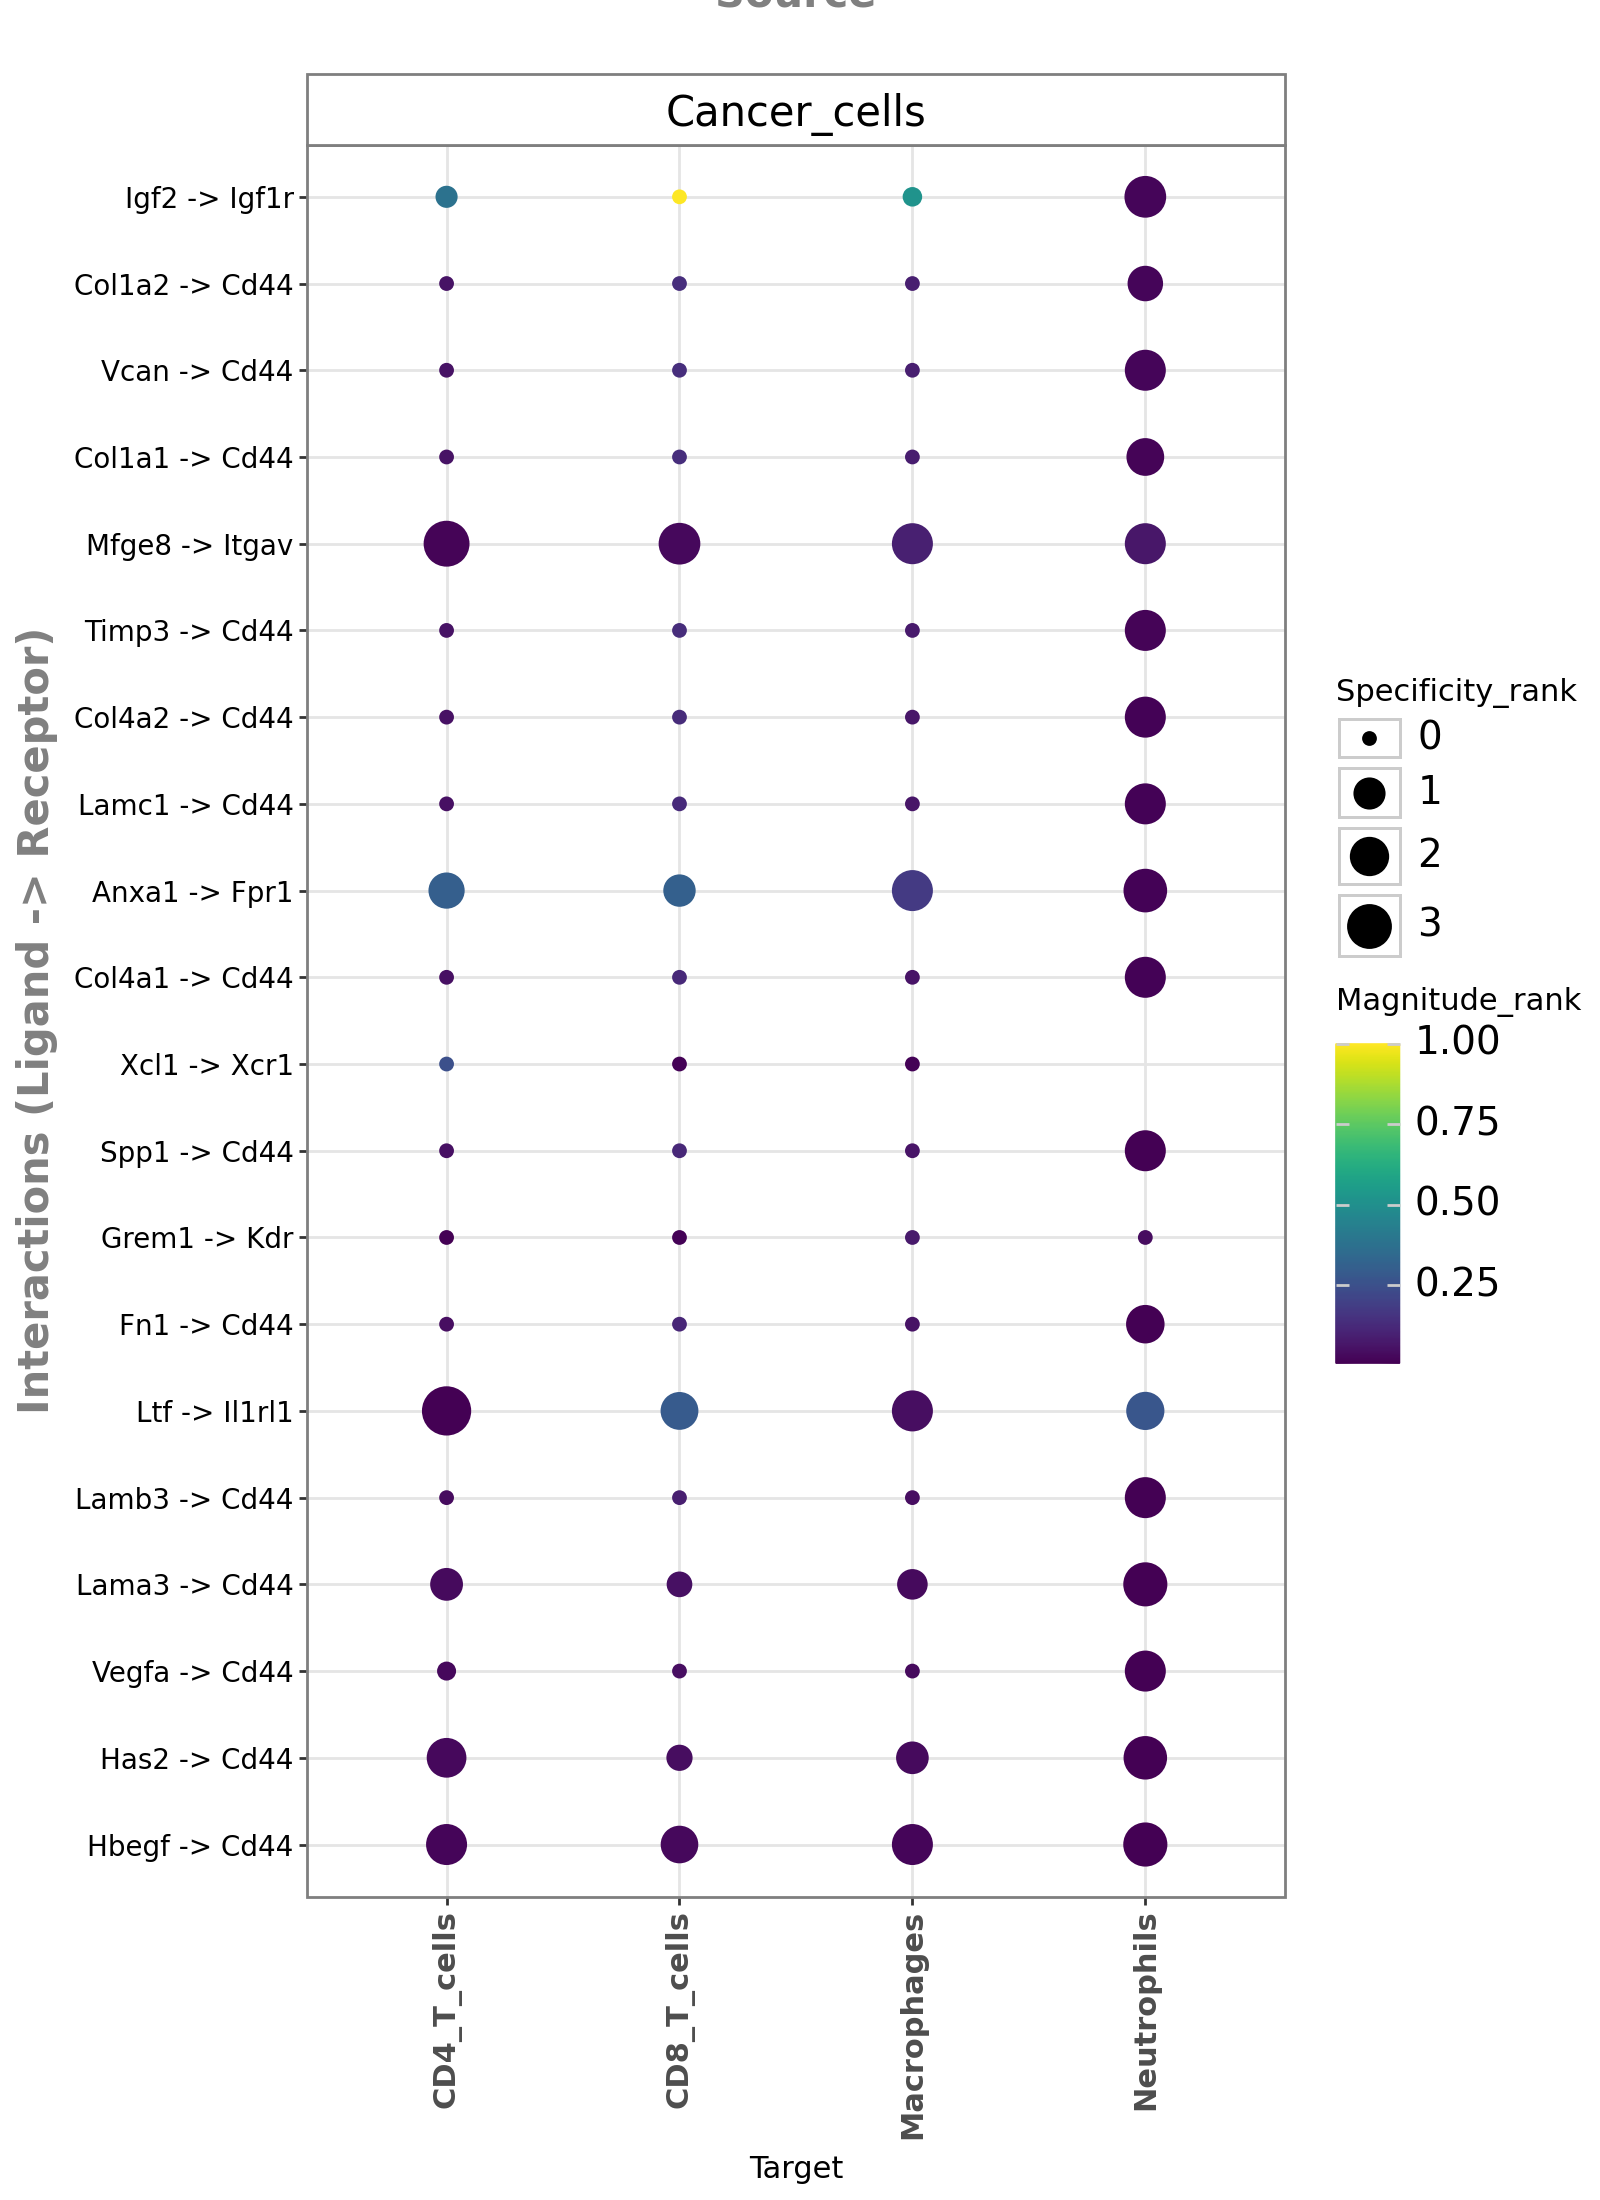

In [27]:
li.pl.dotplot(
    adata,
    colour='magnitude_rank',
    size='specificity_rank',
    source_labels=['Cancer_cells'],
    target_labels=['CD4_T_cells','CD8_T_cells','Macrophages','Neutrophils'],
    inverse_size=True,
    top_n=20,
    orderby='magnitude_rank',
    orderby_ascending=True,
    figure_size=(8, 11)
)

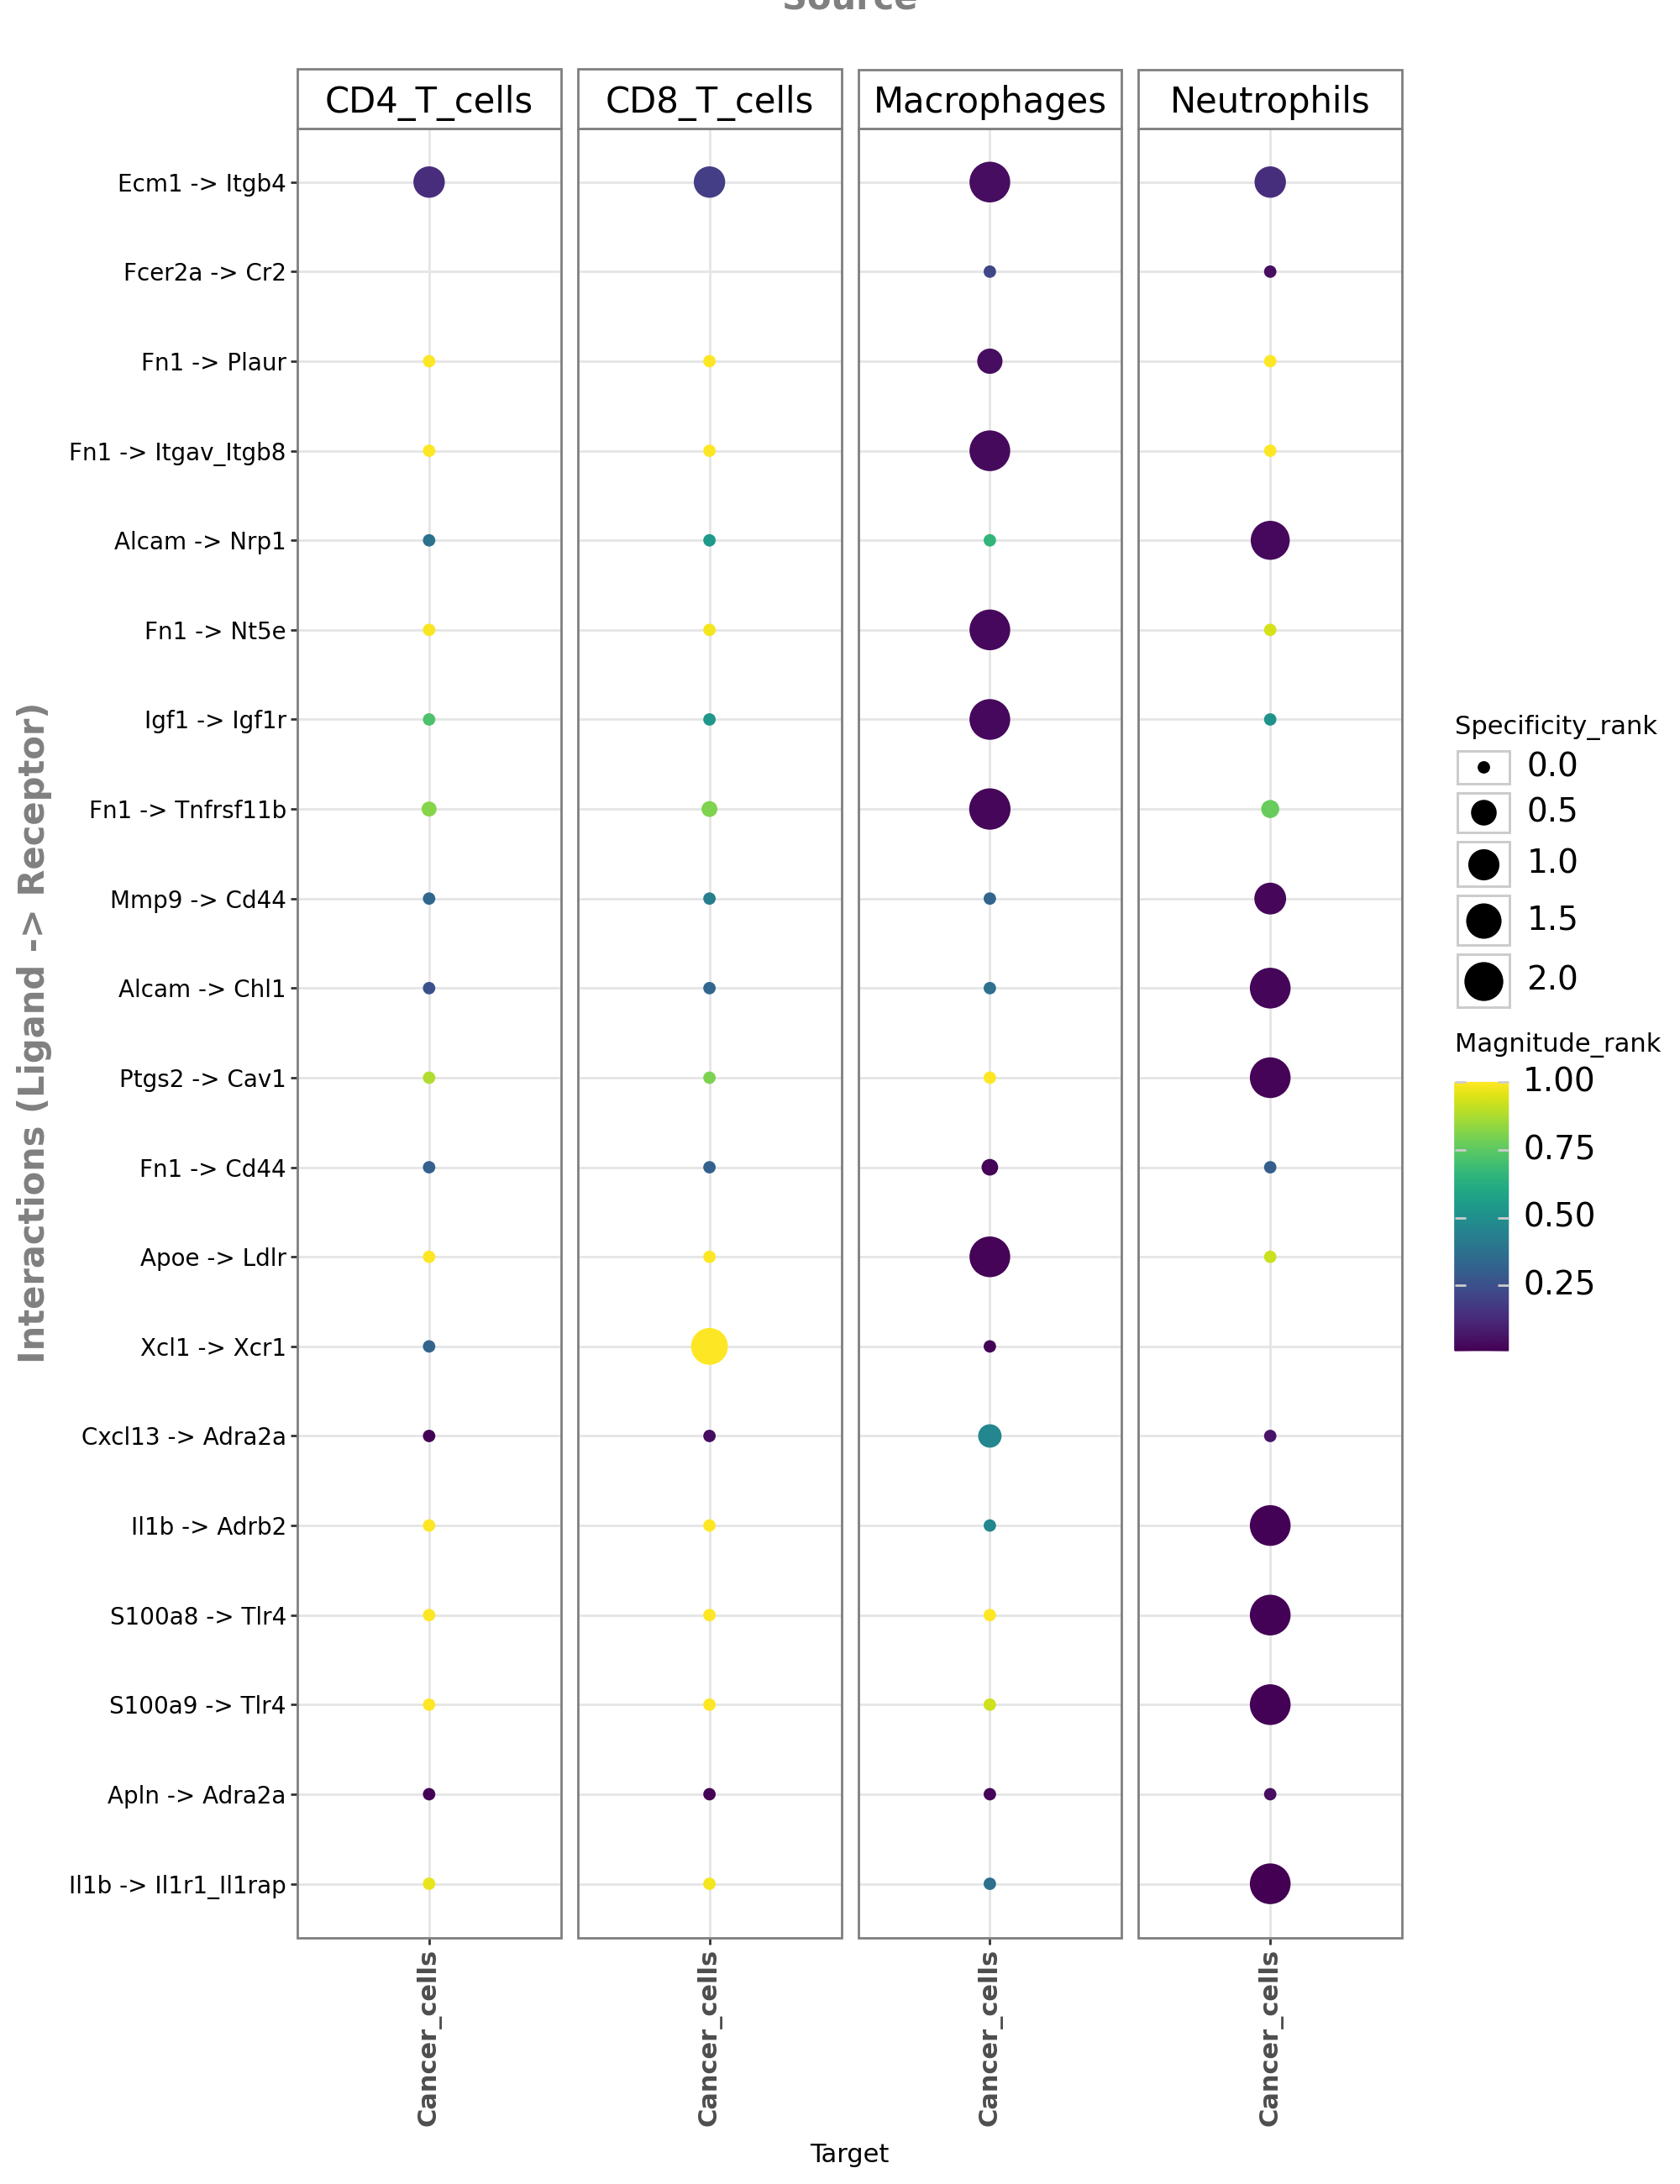

In [31]:
li.pl.dotplot(
    adata,
    colour='magnitude_rank',
    size='specificity_rank',
    source_labels=['CD4_T_cells','CD8_T_cells','Macrophages','Neutrophils'],
    target_labels=['Cancer_cells'],
    inverse_size=True,
    top_n=20,
    orderby='magnitude_rank',
    orderby_ascending=True,
    figure_size=(10,13)
)

## check the L-R expression level by states

In [ ]:
top_k = 30

# DEA

### This check Differential expression between conditions (usually different samples)

In [36]:
import liana as li
import decoupler as dc
import omnipath as op

# adata.obs['sample_id'] = 'E4S'
adata.obs['condition'] = adata.obs['batch'].astype(str).str.startswith('control').map({True: 'CT', False: 'ASO'})
adata.obs['condition']

AAACCCAAGCACTCGC-1-CT_1      CT
AAACCCAAGGATTCAA-1-CT_1      CT
AAACCCAGTACTTGTG-1-CT_1      CT
AAACCCATCACCATAG-1-CT_1      CT
AAACGAACAACCGGAA-1-CT_1      CT
                           ... 
TTTGGTTTCCTCTAAT-1-ASO_3    ASO
TTTGGTTTCTGTCCGT-1-ASO_3    ASO
TTTGTTGAGTGCGACA-1-ASO_3    ASO
TTTGTTGGTCCAGGTC-1-ASO_3    ASO
TTTGTTGGTTCACGAT-1-ASO_3    ASO
Name: condition, Length: 21116, dtype: object

In [39]:
# pdata = dc.pp.pseudobulk(
#     adata,
#     sample_col='condition',
#     groups_col='cell_type',
#     # layer='counts',
#     mode='sum',
#     skip_checks=True
# )
# pdata

AnnData object with n_obs × n_vars = 22 × 2450
    obs: 'condition', 'cell_type', 'predicted_doublet', 'psbulk_cells', 'psbulk_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'chromosome', 'start', 'end'
    layers: 'psbulk_props'

In [40]:
import omnipath as op
import plotnine as p9
import decoupler as dc

#  dea_df should have genes ranked by how differentially expressed 
#  they are between conditions within each cluster

In [50]:
# Run rank_genes_groups for each leiden cluster
groupby = 'cell_type' 
# groupby = 'cluster_annotation'

sc.tl.rank_genes_groups(adata, groupby, method='wilcoxon')

# Extract top 20 genes per cluster into a DataFrame
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
n_genes = 20

df_top_genes = pd.DataFrame({
    group: result['names'][group][:n_genes] for group in groups
})

# Also create a version with scores and pvals
df_detailed = pd.DataFrame()
for group in groups:
    temp_df = pd.DataFrame({
        groupby: group,
        'gene': result['names'][group][:n_genes],
        'scores': result['scores'][group][:n_genes],
        'logfoldchanges': result['logfoldchanges'][group][:n_genes],
        'pvals': result['pvals'][group][:n_genes],
        'pvals_adj': result['pvals_adj'][group][:n_genes],
    })
    df_detailed = pd.concat([df_detailed, temp_df], ignore_index=True)

# Filter df_detailed so it only contains genes present in adata.var_names
df_detailed = df_detailed[df_detailed['gene'].isin(adata.var_names)].copy()
# Set the index to 'gene'
df_detailed.set_index('gene', inplace=True)

In [51]:
df_detailed

,cell_type,scores,logfoldchanges,pvals,pvals_adj
gene,,,,,
Skap1,CD4_T_cells,53.385151,4.813938,0.000000e+00,0.000000e+00
Rabgap1l,CD4_T_cells,52.633652,3.743640,0.000000e+00,0.000000e+00
Camk4,CD4_T_cells,52.549919,4.982739,0.000000e+00,0.000000e+00
Inpp4b,CD4_T_cells,52.095341,4.710770,0.000000e+00,0.000000e+00
Bcl11b,CD4_T_cells,51.762718,4.341664,0.000000e+00,0.000000e+00
...,...,...,...,...,...
Immp2l,B_cell,29.196943,4.750174,2.120517e-187,3.247042e-185
Btla,B_cell,29.092659,5.579312,4.445764e-186,6.407131e-184
Bcl11a,B_cell,28.823717,5.086441,1.082161e-182,1.472941e-180


In [52]:
lr_res = li.multi.df_to_lr(adata,
                           dea_df= df_detailed,
                           resource_name='mouseconsensus', # NOTE: uses HUMAN gene symbols!
                           expr_prop=0.01, # calculated for adata as passed - used to filter interactions
                           groupby=groupby,
                           stat_keys=['scores', 'pvals', 'pvals_adj'],
                           use_raw=False,
                           complex_col='scores', # NOTE: we use the Wald Stat to deal with complexes
                           verbose=True,
                           return_all_lrs=False,
                           )

Using resource `mouseconsensus`.
Using `.X`!
0.96 of entities in the resource are missing from the data.


In [53]:
lr_res.head()

,ligand,receptor,ligand_complex,receptor_complex,source,ligand_scores,ligand_pvals,ligand_pvals_adj,ligand_expr,ligand_props,...,receptor_pvals,receptor_pvals_adj,receptor_expr,receptor_props,interaction_scores,interaction_pvals,interaction_pvals_adj,interaction_expr,interaction_props,interaction
0,Cd28,Cd86,Cd28,Cd86,CD4_T_cells,43.598972,0.0,0.0,1.199392,0.758719,...,0.000000e+00,0.000000e+00,0.830058,0.606670,45.517406,0.000000e+00,0.000000e+00,1.014725,0.682694,Cd28^Cd86
1,Cd28,Cd86,Cd28,Cd86,CD4_T_cells,43.598972,0.0,0.0,1.199392,0.758719,...,5.559190e-201,7.168430e-199,1.210220,0.817958,36.923439,2.779595e-201,3.584215e-199,1.204806,0.788339,Cd28^Cd86
2,Cd28,Cd80,Cd28,Cd80,CD4_T_cells,43.598972,0.0,0.0,1.199392,0.758719,...,0.000000e+00,0.000000e+00,1.269975,0.683931,55.953995,0.000000e+00,0.000000e+00,1.234684,0.721325,Cd28^Cd80
3,Cd86,Cd28,Cd86,Cd28,DC,47.435841,0.0,0.0,0.830058,0.606670,...,0.000000e+00,0.000000e+00,1.199392,0.758719,45.517406,0.000000e+00,0.000000e+00,1.014725,0.682694,Cd86^Cd28
4,Cd86,Ctla4,Cd86,Ctla4,DC,47.435841,0.0,0.0,0.830058,0.606670,...,0.000000e+00,0.000000e+00,1.670715,0.783630,47.111229,0.000000e+00,0.000000e+00,1.250387,0.695150,Cd86^Ctla4


In [54]:
lr_res = lr_res.sort_values("interaction_scores", ascending=False, key=abs)
lr_res.head()

,ligand,receptor,ligand_complex,receptor_complex,source,ligand_scores,ligand_pvals,ligand_pvals_adj,ligand_expr,ligand_props,...,receptor_pvals,receptor_pvals_adj,receptor_expr,receptor_props,interaction_scores,interaction_pvals,interaction_pvals_adj,interaction_expr,interaction_props,interaction
18,Mmp9,Cd44,Mmp9,Cd44,Neutrophils,71.282486,0.0,0.0,1.121100,0.647742,...,0.0,0.0,2.283409,0.895086,72.300919,0.0,0.0,1.702254,0.771414,Mmp9^Cd44
9,Col1a2,Cd44,Col1a2,Cd44,Fibroblasts,58.461121,0.0,0.0,3.629502,0.976043,...,0.0,0.0,2.283409,0.895086,65.890236,0.0,0.0,2.956455,0.935565,Col1a2^Cd44
7,Col1a1,Cd44,Col1a1,Cd44,Fibroblasts,57.978493,0.0,0.0,3.425609,0.970634,...,0.0,0.0,2.283409,0.895086,65.648926,0.0,0.0,2.854509,0.932860,Col1a1^Cd44
10,Col6a1,Cd44,Col6a1,Cd44,Fibroblasts,53.867340,0.0,0.0,1.697353,0.904173,...,0.0,0.0,2.283409,0.895086,63.593346,0.0,0.0,1.990381,0.899630,Col6a1^Cd44
11,Col6a2,Cd44,Col6a2,Cd44,Fibroblasts,52.463078,0.0,0.0,1.524317,0.880216,...,0.0,0.0,2.283409,0.895086,62.891212,0.0,0.0,1.903863,0.887651,Col6a2^Cd44


In [55]:
# Let's visualize how this looks like for all interactions  (across all cell types)
lr_res = lr_res.sort_values("interaction_scores", ascending=False)

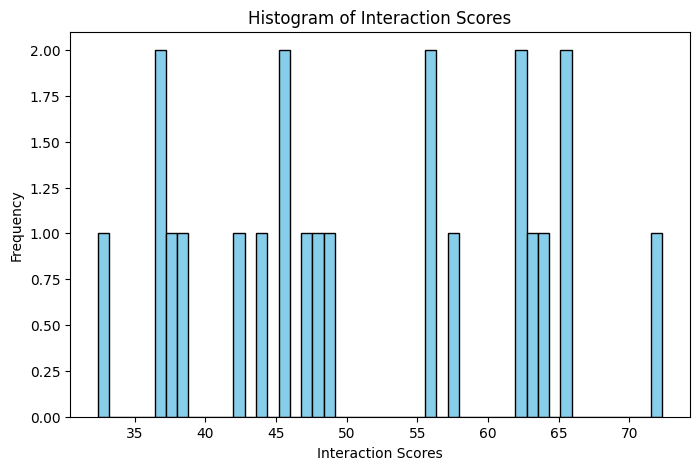

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(lr_res['interaction_scores'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Interaction Scores')
plt.ylabel('Frequency')
plt.title('Histogram of Interaction Scores')
plt.show()

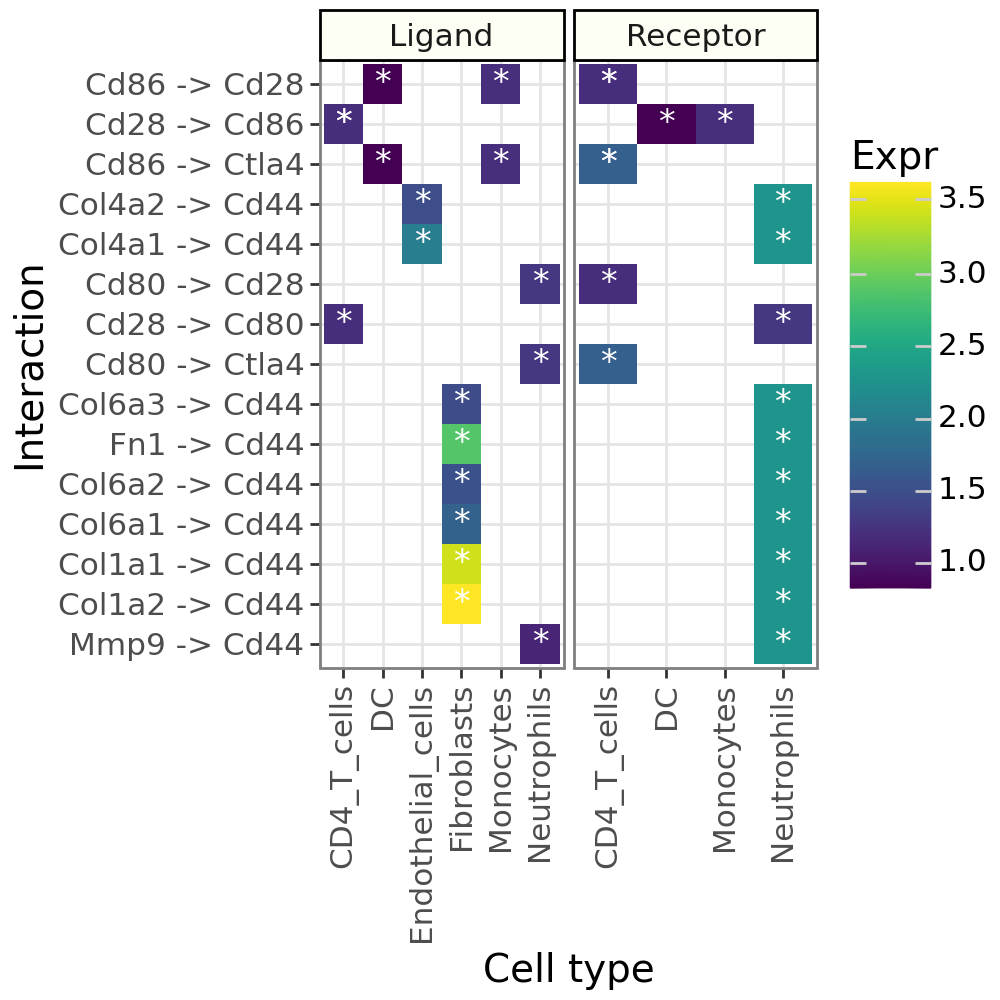

In [57]:
li.pl.tileplot(liana_res=lr_res,
               fill = 'expr',
               label='pvals_adj',
               label_fun = lambda x: '*' if x < 0.05 else np.nan,
               top_n=15,
               orderby = 'interaction_scores',
               orderby_ascending = False,
               orderby_absolute = False,
               source_title='Ligand',
               target_title='Receptor',
               )

In [58]:
print(lr_res['source'].unique())
print(lr_res['target'].unique())

['Neutrophils' 'Fibroblasts' 'CD4_T_cells' 'Endothelial_cells' 'DC'
 'B_cell' 'Monocytes']
['Neutrophils' 'CD4_T_cells' 'DC' 'B_cell' 'CD8_T_cells' 'Monocytes']


In [59]:
plot = li.pl.dotplot(liana_res=lr_res,
                     colour='interaction_scores',
                     size='ligand_pvals',
                     inverse_size=True,
                     orderby='interaction_scores',
                     orderby_ascending=False,
                     orderby_absolute=True,
                     source_labels=['Malign Epithelial','Neutrophil','M1 Mac'],
                     target_labels=['M1 Mac', 'Macrophage', 'M2 Mac'],
                     top_n=15,
                     size_range=(0.5, 4)
                     )
plot.show()

ValueError: ['Malign Epithelial' 'Neutrophil' 'M1 Mac'] not found in `liana_res['source']`!

# DEA correct